# 1D Data Assimilation Example

A simulated 1D data assimilation (DA) example using the variational DA solver from `pyDA_utils`

shawn.s.murdzek@noaa.gov

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure that the directory containing pyDA_utils is part of your PYTHONPATH first
from pyDA_utils.variational_da import ThreeDVar

## Create simulated data

For this example, we will pretend that we have a vertical column of potential temperatures ($\theta$) from a model that we want to update using $\theta$ observations from an uncrewed aircraft system (UAS).

We will further assume that the background errors are correlated in space and that the UAS observation errors are uncorrelated (the latter is a common assumption in DA but can be violated in reality, especially for satellite observations).

In [2]:
# Background model state

# zb = model vertical levels (m AGL)
zb = np.arange(0, 500, 50)

# xb = model potential temperatures (K)
# Assume well-mixed PBL w/ constant theta
xb = np.ones(len(zb)) * 300

# Background error covariances
# Assume nearby levels are correlated using
dist = np.abs(zb[:, np.newaxis] - zb[np.newaxis, :])
bgd_err_std = 0.75
B = (bgd_err_std**2) * np.exp(-dist**2 / (2*(50**2))) 

In [3]:
# UAS observations (it is assumed that these observations are already "superobbed")

# UAS vertical levels (m AGL)
zo = np.arange(75, 500, 150)

# Observed potential temperatures (K)
# Add random Gaussian errors
obs_err_std = 0.3
yo = 300 + 0.005 * zo + np.random.normal(scale=obs_err_std, size=len(zo))

# Observation error covariance matrix
# Assume obs are uncorrelated (i.e., R is diagonal)
R = np.diag(np.ones(len(yo)) * (obs_err_std**2))

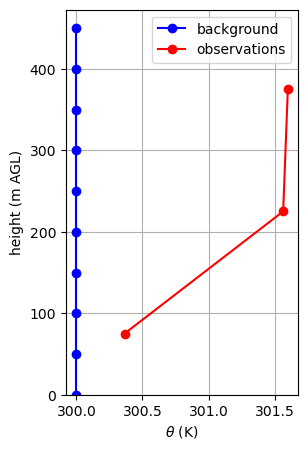

In [4]:
# Plot background and observations

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 5))

ax.plot(xb, zb, 'b-', marker='o', label='background')
ax.plot(yo, zo, 'r-', marker='o', label='observations')

ax.legend()
ax.set_xlabel(r'$\theta$ (K)')
ax.set_ylabel('height (m AGL)')
ax.grid()
ax.set_ylim(bottom=0)

plt.show()

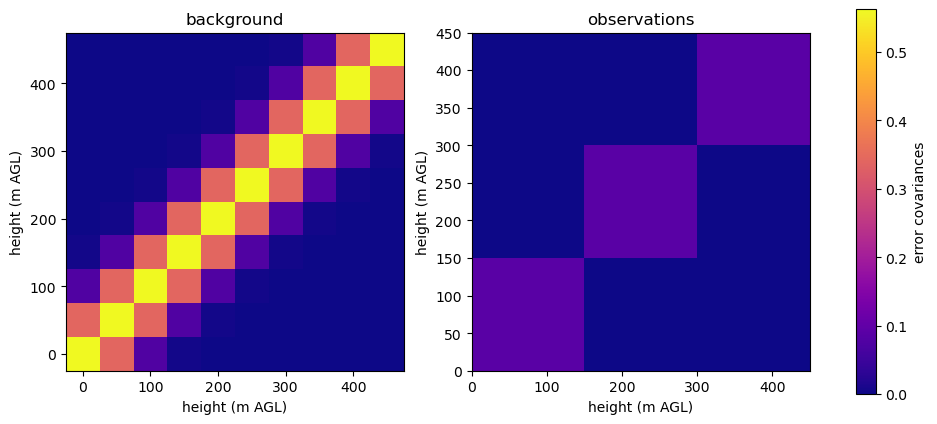

In [5]:
# Plot error covariance matrices

vmin = min(np.amin(R), np.amin(B))
vmax = max(np.amax(R), np.amax(B))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

for i, (z, M, ttl) in enumerate(zip([zb, zo], [B, R], ['background', 'observations'])):
    ax = axes[i]
    
    cax = ax.pcolormesh(z, z, M, cmap='plasma', vmin=vmin, vmax=vmax)

    ax.set_aspect('equal')
    ax.set_xlabel('height (m AGL)')
    ax.set_ylabel('height (m AGL)')
    ax.set_title(ttl)

cbar = plt.colorbar(cax, ax=axes, orientation='vertical')
cbar.set_label('error covariances')
plt.show()

## Define forward operator

The forward operator (H) maps the background model state to the observations. In our case, we will use linear interpolation. No variable transforms are needed because we are directly observing the model state (i.e., both the model background and observations are $\theta$). 

In [6]:
# NOTE: H must only have 1 positional argument (xb), otherwise the "assimilate" method used below will through an error
# Therefore, we will pass the locations as keyword arguments

def H(xb, zb=zb, zo=zo):
    """
    Interpolate model background to observation locations

    Inputs
    ------
    xb : np.array
        Model background values
    zb : np.array, optional
        Observation locations
    zo : np.array, optional
        Model background locations

    Returns
    -------
    Model background interpolated to observation locations
    """
    
    return np.interp(zo, zb, xb)

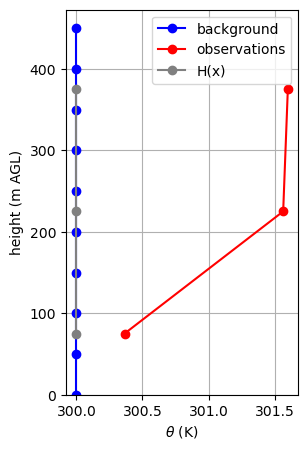

In [7]:
# Plot output from forward operator

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 5))

ax.plot(xb, zb, 'b-', marker='o', label='background')
ax.plot(yo, zo, 'r-', marker='o', label='observations')
ax.plot(H(xb), zo, c='gray', ls='-', marker='o', label='H(x)')

ax.legend()
ax.set_xlabel(r'$\theta$ (K)')
ax.set_ylabel('height (m AGL)')
ax.grid()
ax.set_ylim(bottom=0)

plt.show()

## Perform DA

Here, we will use a variational solver, which minimizes a cost function to find the most likely analysis state.

In [8]:
# Use ThreeDVar from pyDA_utils

# Construct ThreeDVar object, which stores B, R, and H
# This also computes the inverse of B and R (needed for cost function minimization)
var_obj = ThreeDVar(B, R, H)

# Assimilate obs. Note that we don't need the second output, hence the _
xa, _ = var_obj.assimilate(xb, yo)

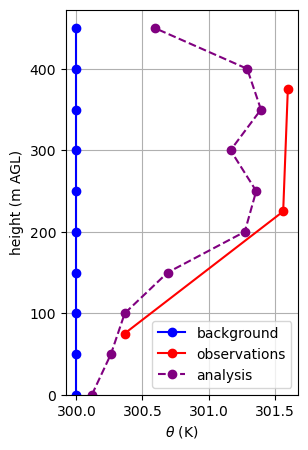

In [9]:
# Plot DA results

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 5))

ax.plot(xb, zb, 'b-', marker='o', label='background')
ax.plot(yo, zo, 'r-', marker='o', label='observations')
ax.plot(xa, zb, c='purple', ls='--', marker='o', label='analysis')

ax.legend()
ax.set_xlabel(r'$\theta$ (K)')
ax.set_ylabel('height (m AGL)')
ax.grid()
ax.set_ylim(bottom=0)

plt.show()